In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [3]:
### read csv
df=pd.read_csv(r"D:\dataanalytics\Data\Airbnb_Open_Data.csv")
df.head()

C:\Users\akhil\AppData\Local\Temp\ipykernel_3700\1440517315.py:2: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(r"D:\dataanalytics\Data\Airbnb_Open_Data.csv")


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [5]:
df.shape

(102599, 26)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [7]:
df.describe()

,id,host id,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,1.025990e+05,1.025990e+05,102591.000000,102591.000000,102385.000000,102190.000000,102416.000000,86720.000000,102273.000000,102280.000000,102151.000000
mean,2.914623e+07,4.925411e+10,40.728094,-73.949644,2012.487464,8.135845,27.483743,1.374022,3.279106,7.936605,141.133254
std,1.625751e+07,2.853900e+10,0.055857,0.049521,5.765556,30.553781,49.508954,1.746621,1.284657,32.218780,135.435024
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,1.508581e+07,2.458333e+10,40.688740,-73.982580,2007.000000,2.000000,1.000000,0.220000,2.000000,1.000000,3.000000
50%,2.913660e+07,4.911774e+10,40.722290,-73.954440,2012.000000,3.000000,7.000000,0.740000,3.000000,1.000000,96.000000
75%,4.320120e+07,7.399650e+10,40.762760,-73.932350,2017.000000,5.000000,30.000000,2.000000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


In [8]:
### Detect noisy data
unique_value={}
for col in df.columns:
    unique_value[col]=df[col].unique()
print(unique_value)

{'id': array([ 1001254,  1002102,  1002403, ..., 57366313, 57366865, 57367417],
      shape=(102058,)), 'NAME': array(['Clean & quiet apt home by the park', 'Skylit Midtown Castle',
       'THE VILLAGE OF HARLEM....NEW YORK !', ...,
       'Elmhurst 1st Fl Rightl Bedroom',
       'Elmhurst 1st Floor BR w/ Pvt. Bath&Balcony',
       'Parisian Style Apartment in Heart of Brooklyn'],
      shape=(61282,), dtype=object), 'host id': array([80014485718, 52335172823, 78829239556, ..., 23801060917,
       15593031571, 93578954226], shape=(102057,)), 'host_identity_verified': array(['unconfirmed', 'verified', nan], dtype=object), 'host name': array(['Madaline', 'Jenna', 'Elise', ..., 'Anna B', 'Natalie And Dan',
       'Apostle John'], shape=(13191,), dtype=object), 'neighbourhood group': array(['Brooklyn', 'Manhattan', 'brookln', 'manhatan', 'Queens', nan,
       'Staten Island', 'Bronx'], dtype=object), 'neighbourhood': array(['Kensington', 'Midtown', 'Harlem', 'Clinton Hill', 'East Harlem',


In [9]:
# Dtect duplicate value
df.duplicated().sum()

np.int64(541)

In [14]:
#Detect null value
df.isnull().sum()

id                                     0
NAME                                 250
host id                                0
host_identity_verified               289
host name                            404
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       400
number of reviews                    183
last review                        15832
reviews per month                  15818
review rate number                   319
calculated host listings count       319
availability 365                     448
house_rules     

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

In [15]:
### Remove $ sign 
df['price'] = df['price'].replace('[\$,]', '', regex=True).astype(float)
df['service fee'] = df['service fee'].replace('[\$,]','',regex=True).astype(float)

In [16]:
df['price']

0          966.0
1          142.0
2          620.0
3          368.0
4          204.0
           ...  
102053     696.0
102054     909.0
102055     387.0
102056     848.0
102057    1128.0
Name: price, Length: 102058, dtype: float64

In [17]:
# Convert 'last review' to datetime and handle errors
df['last review'] = pd.to_datetime(df['last review'], errors='coerce')

# Fill missing values
df.fillna({'reviews per month': 0, 'last review': df['last review'].min()}, inplace=True)

# Drop records with missing 'name' or 'host name'
df.dropna(subset=['NAME', 'host name'], inplace=True)

In [18]:
df.isnull().sum()

id                                     0
NAME                                   0
host id                                0
host_identity_verified               276
host name                              0
neighbourhood group                   26
neighbourhood                         16
lat                                    8
long                                   8
country                              526
country code                         122
instant_bookable                      96
cancellation_policy                   70
room type                              0
Construction year                    200
price                                239
service fee                          268
minimum nights                       394
number of reviews                    182
last review                            0
reviews per month                      0
review rate number                   307
calculated host listings count       318
availability 365                     420
house_rules     

### Visualization

###### Distribution of Prices
###### Plot the distribution of listing prices.

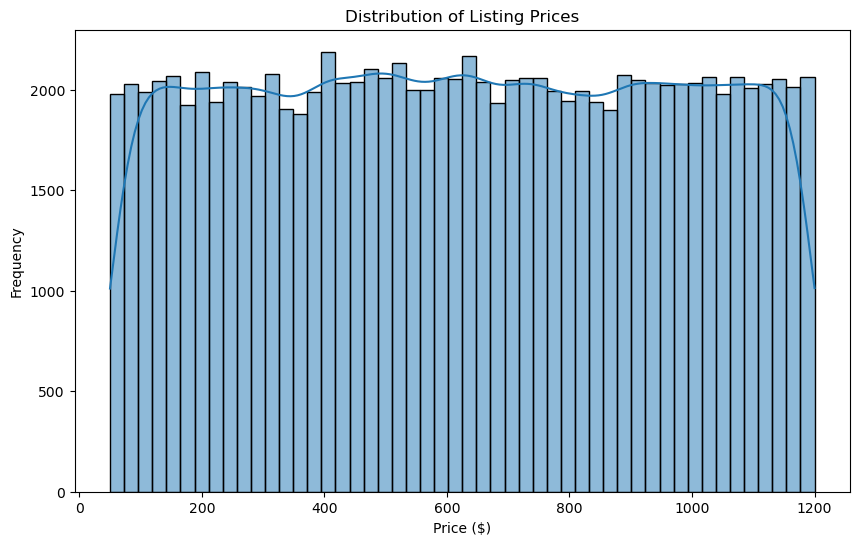

In [23]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'],bins=50,kde=True)
plt.title('Distribution of Listing Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

### Key insight:
- Most Airbnb listings are priced within a moderate range.
- There are a few high-priced outliers, indicating some premium listings with significantly higher prices.

###### Room Type Analysis
###### Analyze the distribution of different room types.

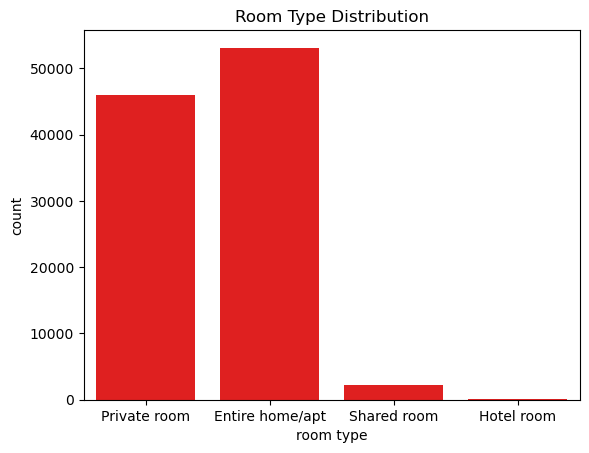

In [28]:
sns.countplot(data=df, x='room type',color='red')
plt.title('Room Type Distribution')
plt.show()

#### Key insight
- The majority of listings are either entire homes/apartments or private rooms.
- Shared rooms and hotel rooms constitute a very small portion of the listings.

##### Neighborhood Analysis
##### Examine how listings are distributed across different neighborhoods.

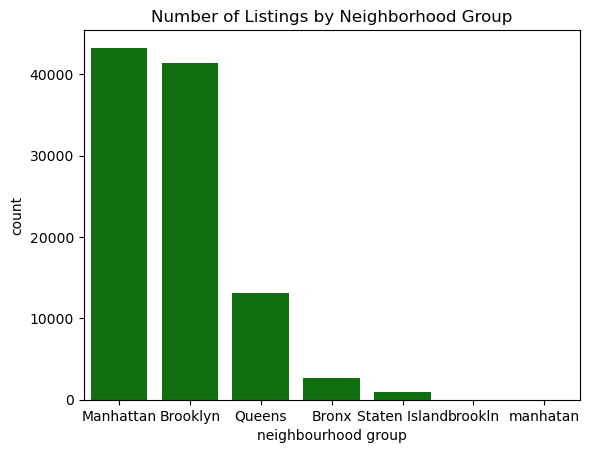

In [36]:
sns.countplot(x='neighbourhood group', data=df,color="green" , order=df['neighbourhood group'].value_counts().index)
plt.title('Number of Listings by Neighborhood Group')
plt.show()

#### Key insight
- Listings are predominantly concentrated in popular areas like Brooklyn and Manhattan.
- Other boroughs such as Queens, Bronx, and Staten Island have fewer listings.

##### Price vs. Room Type
##### Visualize the relationship between price and room type.

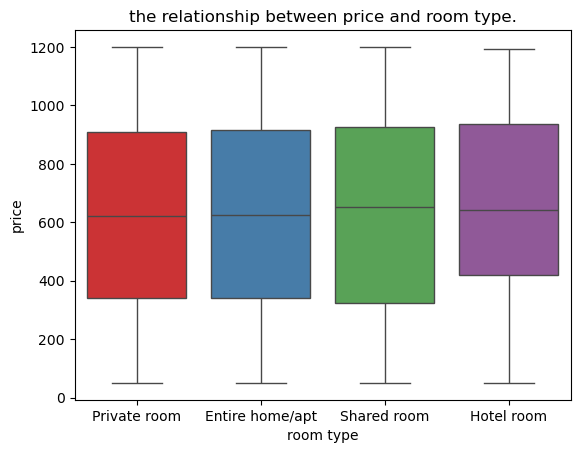

In [43]:
sns.boxplot(data=df,x='room type',y='price',hue='room type', palette='Set1')
plt.title('the relationship between price and room type.')
plt.show()

#### Key insight
- Entire homes/apartments generally cost more than private rooms.
- Shared rooms tend to have the lowest prices among the room types.

###### Reviews Over Time
##### Plot the number of reviews over time.

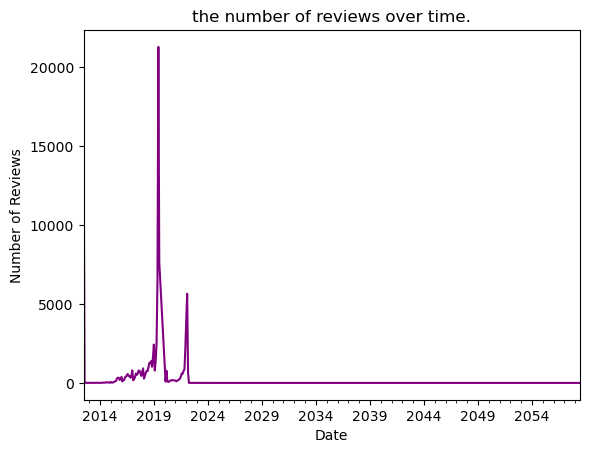

In [42]:
df['last review'] = pd.to_datetime(df['last review'])
reviews_over_time = df.groupby(df['last review'].dt.to_period('M')).size()
reviews_over_time.plot(kind='line',color='purple')
plt.title('the number of reviews over time.')
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.show()

#### Key insight
- Seasonal Trends in Reviews:
- There are observable seasonal trends in the number of reviews.
- Certain months experience higher review activity,

In [44]:
#### Multi varient analysis
df_num=df.select_dtypes(include='number')
df_num

,id,host id,lat,long,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
0,1001254,80014485718,40.64749,-73.97237,2020.0,966.0,193.0,10.0,9.0,0.21,4.0,6.0,286.0
1,1002102,52335172823,40.75362,-73.98377,2007.0,142.0,28.0,30.0,45.0,0.38,4.0,2.0,228.0
2,1002403,78829239556,40.80902,-73.94190,2005.0,620.0,124.0,3.0,0.0,0.00,5.0,1.0,352.0
4,1003689,92037596077,40.79851,-73.94399,2009.0,204.0,41.0,10.0,9.0,0.10,3.0,1.0,289.0
5,1004098,45498551794,40.74767,-73.97500,2013.0,577.0,115.0,3.0,74.0,0.59,3.0,1.0,374.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
102053,57365208,77326652202,40.64945,-73.96108,NaN,696.0,NaN,7.0,12.0,0.44,5.0,1.0,0.0
102054,57365760,45936254757,40.69872,-73.92718,NaN,909.0,NaN,1.0,19.0,0.72,3.0,2.0,0.0
102055,57366313,23801060917,40.67810,-73.90822,NaN,387.0,NaN,2.0,50.0,3.12,4.0,2.0,235.0
102056,57366865,15593031571,40.81248,-73.94317,NaN,848.0,NaN,2.0,0.0,0.00,1.0,1.0,0.0


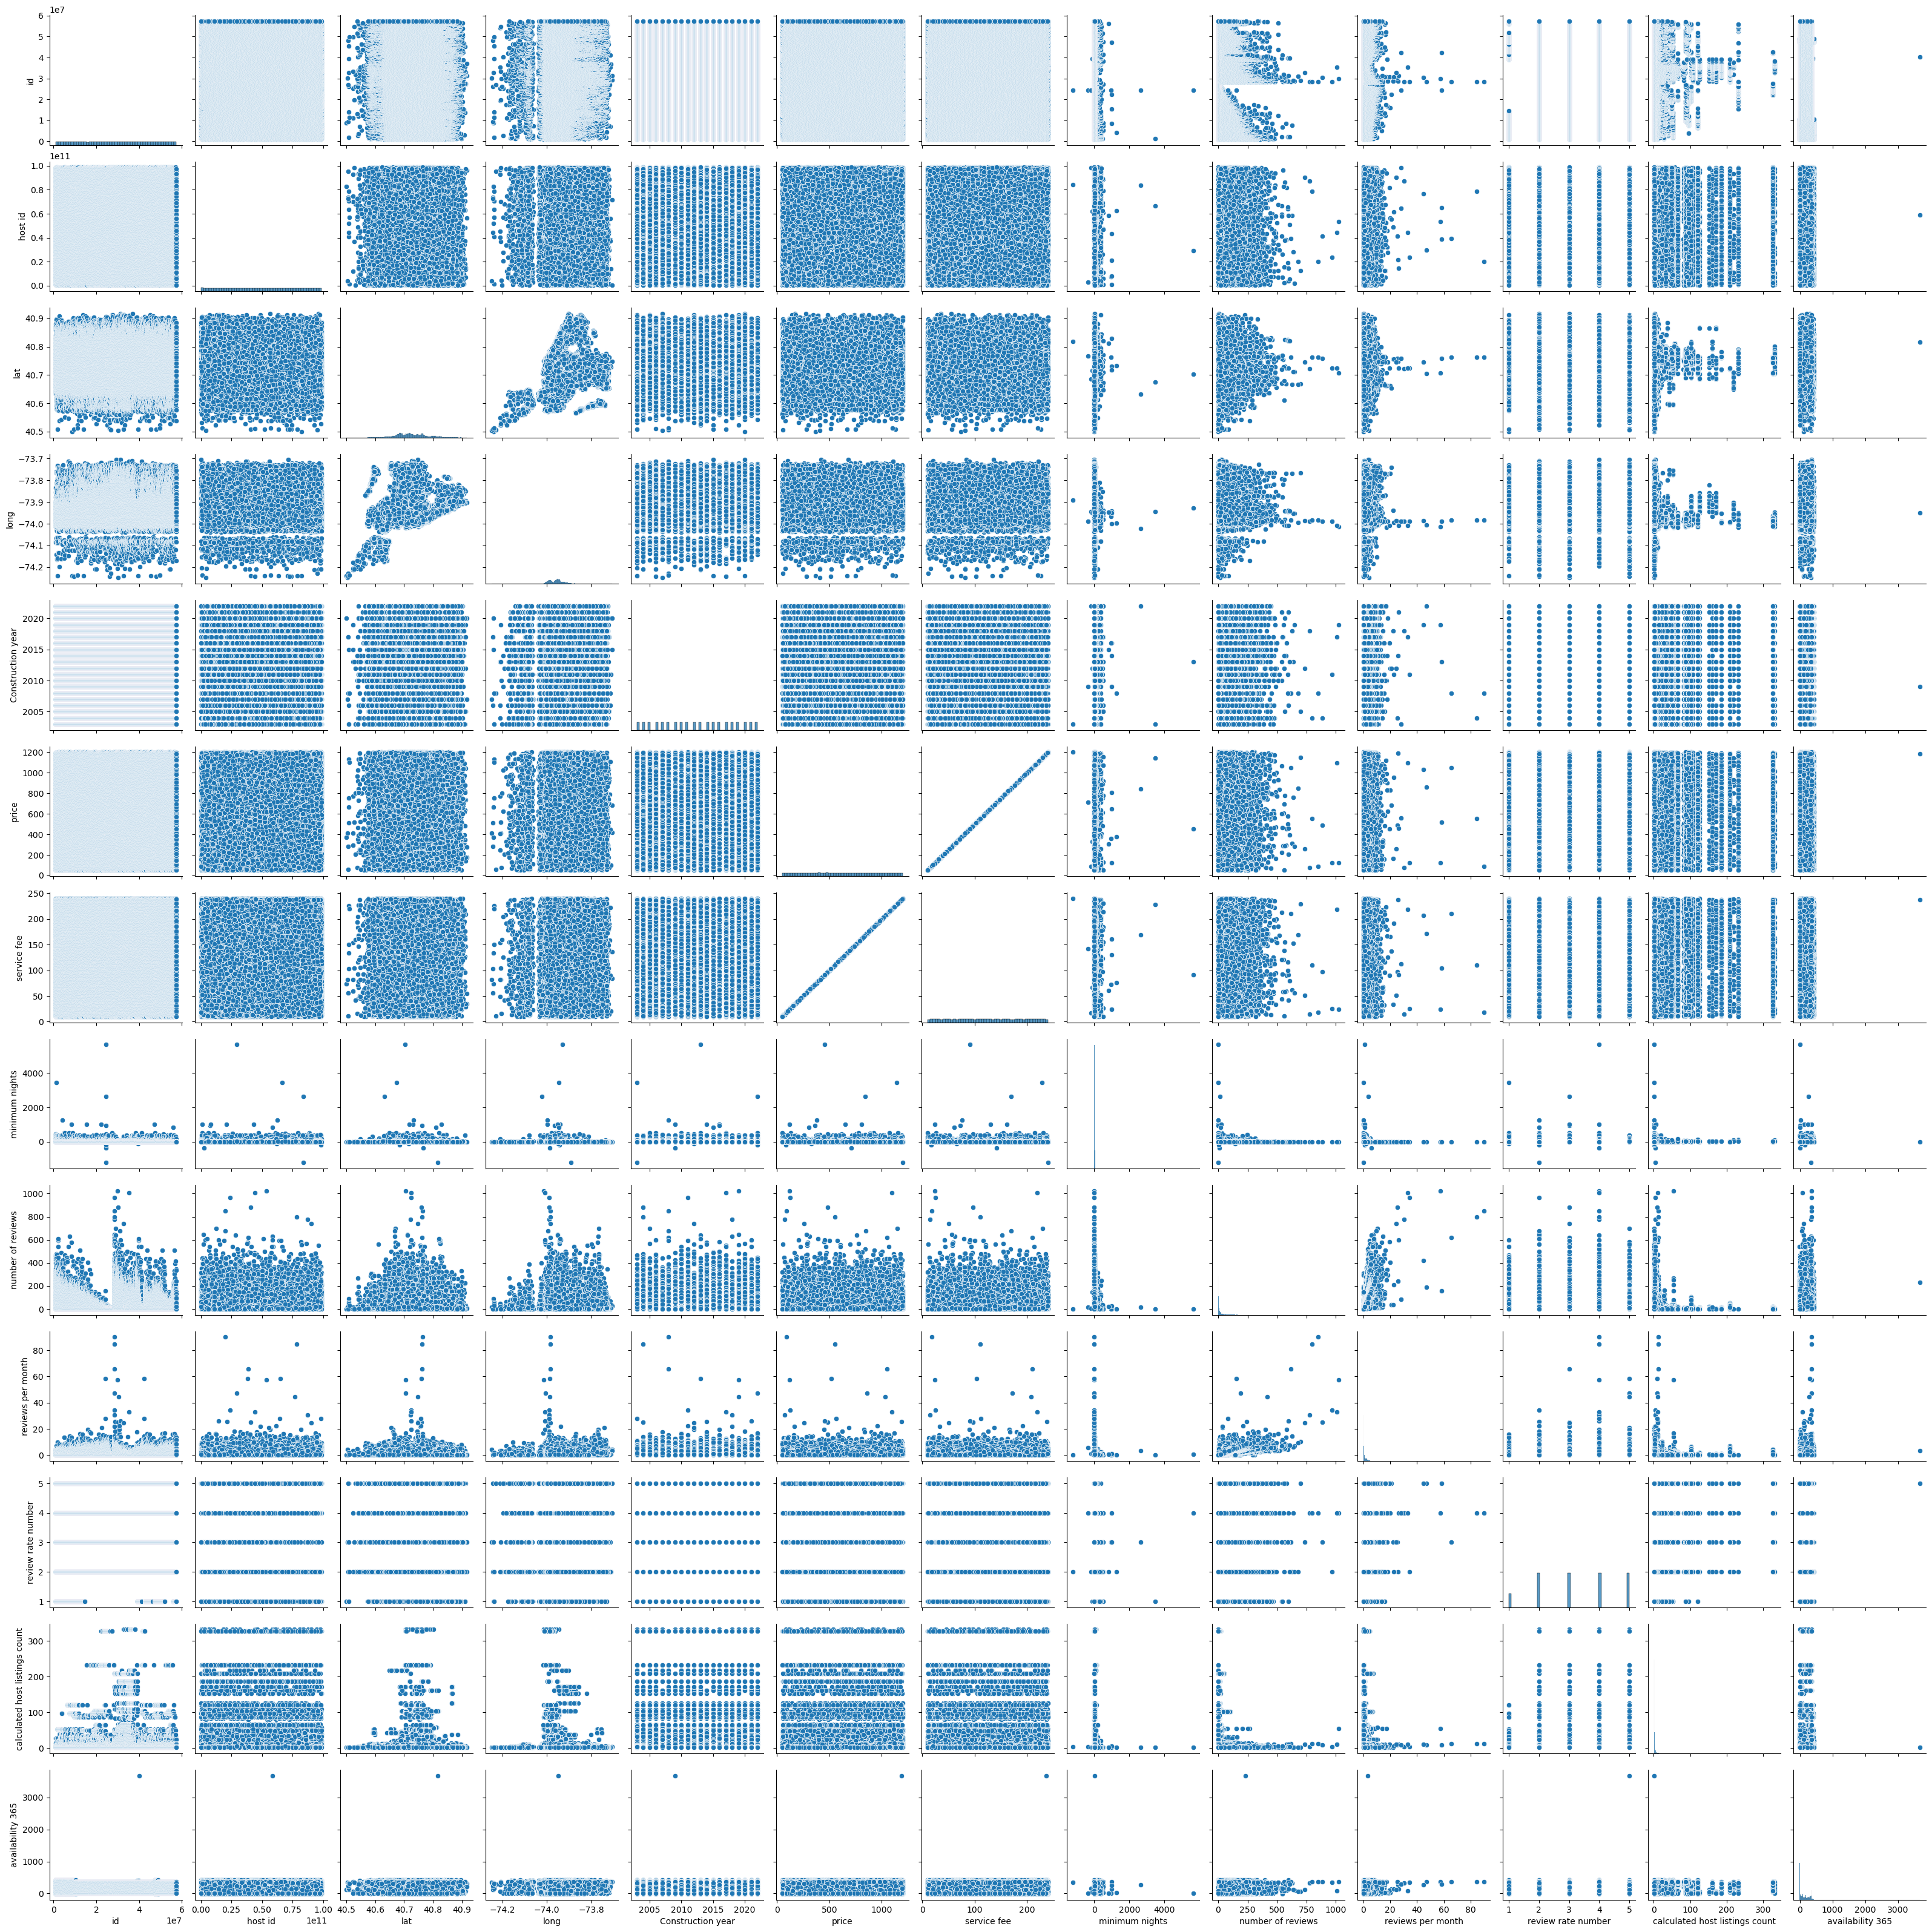

In [45]:
sns.pairplot(df_num)

<Axes: >

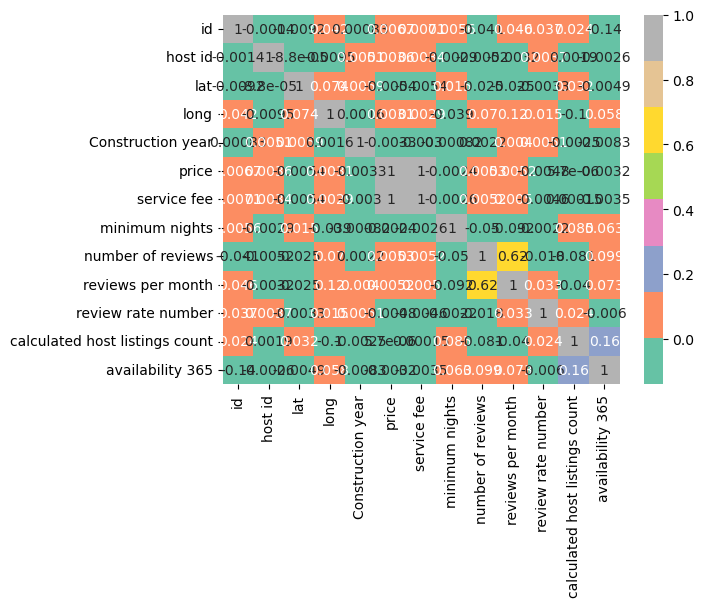

In [49]:
sns.heatmap(df_num.corr(),annot=True,cmap='Set2')